In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets
from IPython.display import display

In [ ]:
def get_fft(image, log=True, padding=None):

    if padding:
        fft = np.fft.fft2(image, s=padding)
    else:
        fft = np.fft.fft2(image)

    fft_shifted = np.fft.fftshift(fft)

    if log:
        return np.log(np.abs(fft_shifted) + 1)

    return np.abs(fft_shifted)

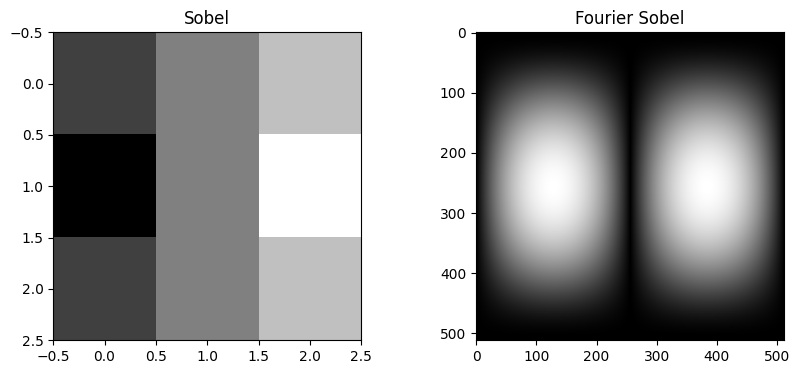

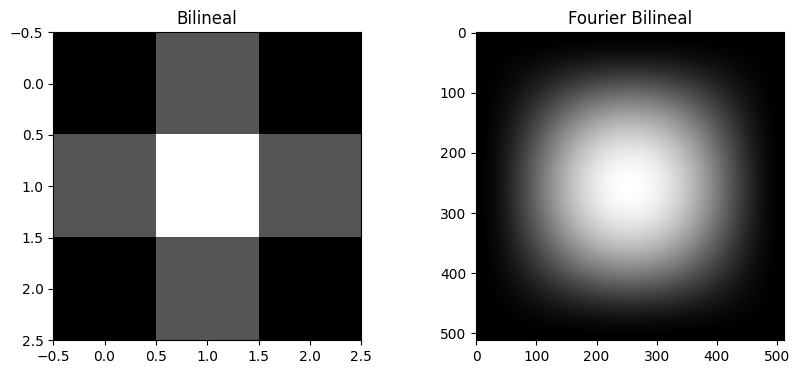

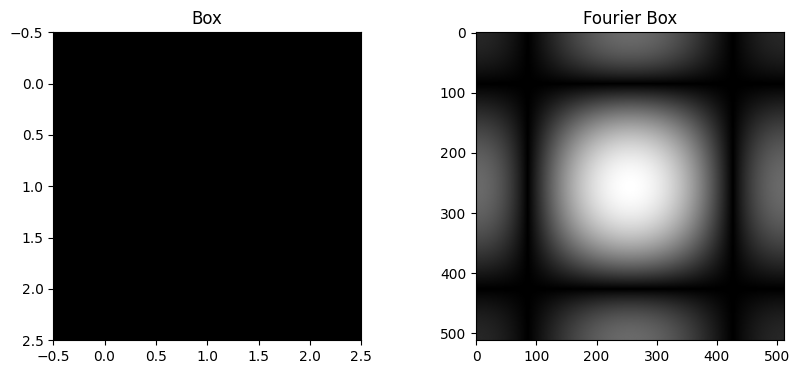

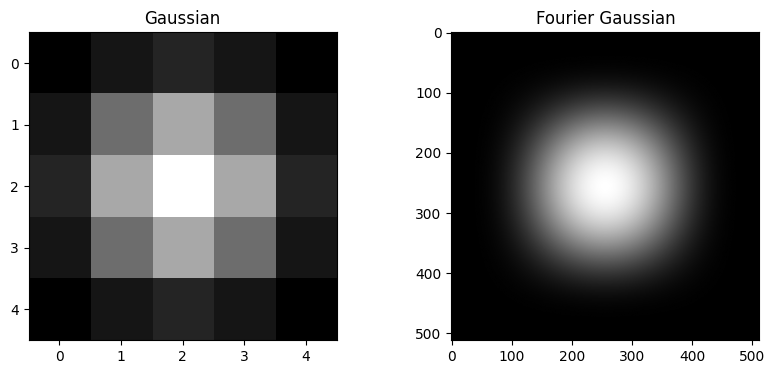

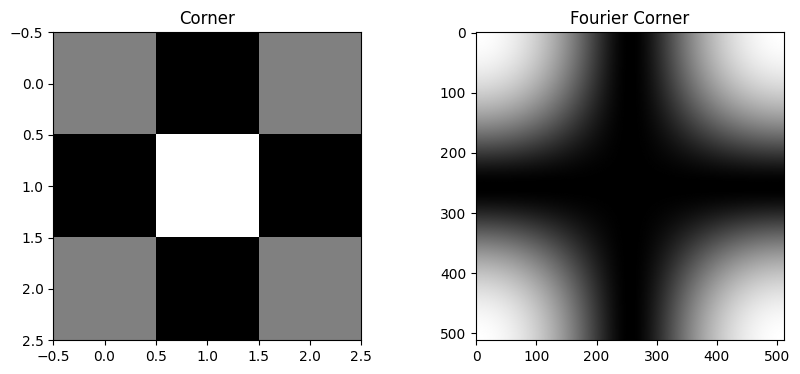

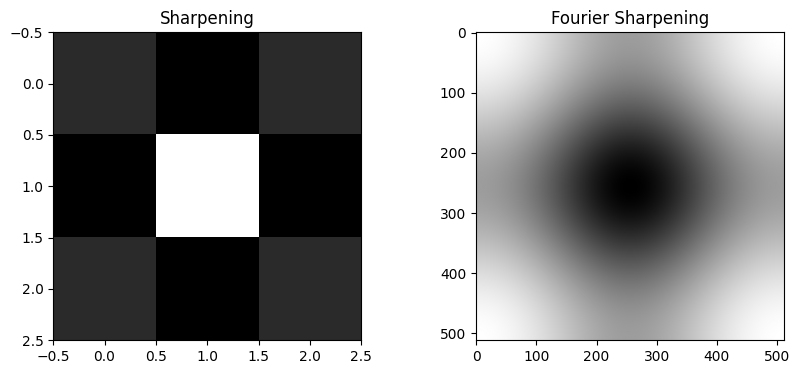

In [ ]:
# Transformada de fourier y filtros lineales

kernel_sobel = (1/8) * np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
], dtype=np.float32)

kernel_bilineal = (1/16) * np.array([
[1,2,1],
[2,4,2],
[1,2,1]
], dtype=np.float32)

kernel_box = (1/9) * np.ones((3,3))

kernel_gaussian = (1/256) * np.array([
[1,4,6,4,1],
[4,16,24,16,4],
[6,24,36,24,6],
[4,16,24,16,4],
[1,4,6,4,1]
], dtype=np.float32)

kernel_corner = (1/4) * np.array([
[1,-2,1],
[-2,4,-2],
[1,-2,1]
], dtype=np.float32)

kernel_sharpening = (1/4) * np.array([
[0,-1,0],
[-1,5,-1],
[0,-1,0]
], dtype=np.float32)

filters = {
"Sobel": kernel_sobel,
"Bilineal": kernel_bilineal,
"Box": kernel_box,
"Gaussian": kernel_gaussian,
"Corner": kernel_corner,
"Sharpening": kernel_sharpening
}

for name, f in filters.items():

    fft_img = get_fft(f, True, padding=(512,512))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(f, cmap="gray")
    plt.title(name)

    plt.subplot(1,2,2)
    plt.imshow(fft_img, cmap="gray")
    plt.title("Fourier "+name)

    plt.show()

In [ ]:
# Espectro en tiempo real con cámara
# ACUERDATE QUE PARA SALIR DE CAMARA YO SIEMPRE OCUPO "Q"

def spectrum(img):

    img = np.float32(img)

    img_dft = cv2.dft(img, flags=cv2.DFT_COMPLEX_OUTPUT)
    img_dft_shifted = np.fft.fftshift(img_dft)

    img_mag = cv2.magnitude(img_dft_shifted[:,:,0], img_dft_shifted[:,:,1])

    return np.log(img_mag + 1)


camara = cv2.VideoCapture(0)

print("Oprime q para salir")

while True:

    ret, frame = camara.read()

    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    frame_fft = spectrum(frame_gray)

    cv2.normalize(frame_fft, frame_fft, 0,255, cv2.NORM_MINMAX)

    mag = np.uint8(frame_fft)

    frame_show = np.hstack((frame_gray, mag))

    cv2.imshow("Camara Fourier", frame_show)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

camara.release()
cv2.destroyAllWindows()

Oprime q para salir


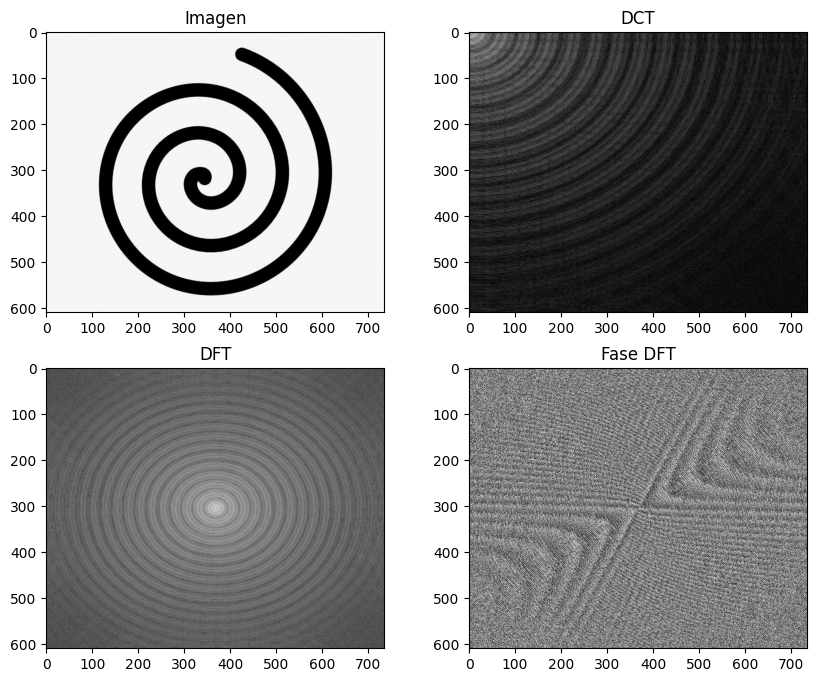

In [ ]:
# Comparacion DFT vs DCT
# Aqui tienes que evaluar todas las imagenes del repo segun las instrucciones

img = cv2.imread("img/espiral.jpg", cv2.IMREAD_GRAYSCALE)

img = np.float32(img)

dct = cv2.dct(img)
dct_spec = np.log(np.abs(dct) + 1)

fft = np.fft.fft2(img)
fft_shift = np.fft.fftshift(fft)

fft_spec = np.log(np.abs(fft_shift) + 1)

fft_phase = np.angle(fft_shift)

fig, axs = plt.subplots(2,2, figsize=(10,8))

axs[0,0].imshow(img, cmap="gray")
axs[0,0].set_title("Imagen")

axs[0,1].imshow(dct_spec, cmap="gray")
axs[0,1].set_title("DCT")

axs[1,0].imshow(fft_spec, cmap="gray")
axs[1,0].set_title("DFT")

axs[1,1].imshow(fft_phase, cmap="gray")
axs[1,1].set_title("Fase DFT")

plt.show()